--- Task E-06: Feature Importance Pre-Analysis ---
Feature table: (2850, 12)

Correlation with order_count:
rolling_12w     0.984
rolling_4w      0.981
lag_52w         0.977
lag_2w          0.972
lag_1w          0.971
lag_4w          0.970
is_holiday      0.023
is_winter      -0.005
month          -0.017
week_of_year   -0.018


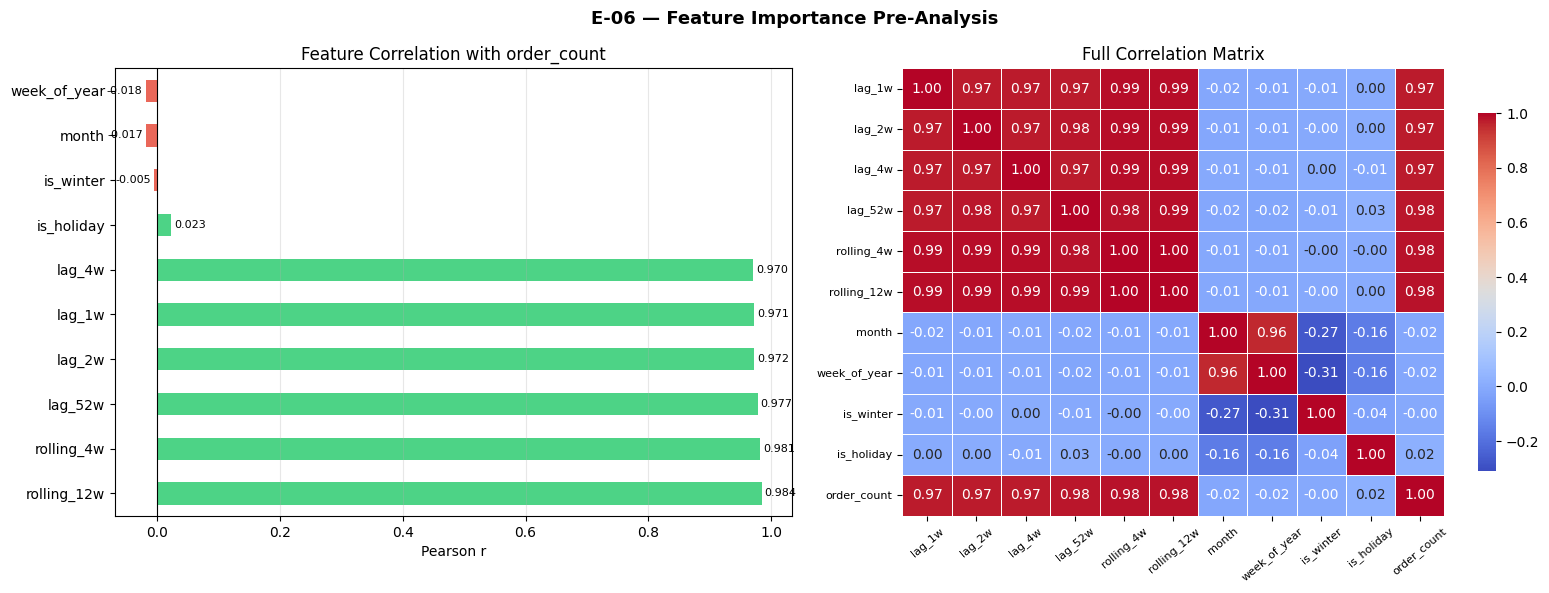

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("--- Task E-06: Feature Importance Pre-Analysis ---")
ROOT      = Path.cwd().parents[1]
DATA_DIR  = ROOT / "data"
DOCS_DIR  = ROOT / "docs"
DOCS_DIR.mkdir(exist_ok=True)

orders_path   = DATA_DIR / "orders.parquet"
holidays_path = DATA_DIR / "holidays.parquet"

orders_df   = pd.read_parquet(orders_path)
holidays_df = pd.read_parquet(holidays_path)

orders_df['region']     = orders_df['region'].str.strip()
orders_df['created_at'] = pd.to_datetime(orders_df['created_at'])
holidays_df['date']     = pd.to_datetime(holidays_df['date'])

weekly_demand = (
    orders_df
    .groupby(['region', pd.Grouper(key='created_at', freq='W-MON')])
    .size()
    .reset_index(name='order_count')
)

holiday_weeks = holidays_df['date'].dt.floor('D').unique()

global_weeks = pd.date_range(
    start=weekly_demand['created_at'].min(),
    end=weekly_demand['created_at'].max(),
    freq='W-MON'
)

processed_list = []

for region, group in weekly_demand.groupby('region'):
    group = group.set_index('created_at').reindex(global_weeks)
    group['order_count'] = group['order_count'].fillna(0)
    group['region']      = region

    group['lag_1w']       = group['order_count'].shift(1)
    group['lag_2w']       = group['order_count'].shift(2)
    group['lag_4w']       = group['order_count'].shift(4)
    group['lag_52w']      = group['order_count'].shift(52)
    group['rolling_4w']   = group['order_count'].shift(1).rolling(4,  min_periods=2).mean()
    group['rolling_12w']  = group['order_count'].shift(1).rolling(12, min_periods=4).mean()
    group['month']        = group.index.month
    group['week_of_year'] = group.index.isocalendar().week.astype(int)
    group['is_winter']    = group['month'].isin([12, 1, 2]).astype(int)
    group['is_holiday']   = group.index.floor('D').isin(holiday_weeks).astype(int)

    processed_list.append(group)

final_df = pd.concat(processed_list).dropna()
print(f"Feature table: {final_df.shape}")

feature_cols = [
    'lag_1w', 'lag_2w', 'lag_4w', 'lag_52w',
    'rolling_4w', 'rolling_12w',
    'month', 'week_of_year', 'is_winter', 'is_holiday',
    'order_count'
]

corr_matrix  = final_df[feature_cols].corr()
corr_target  = corr_matrix['order_count'].drop('order_count').sort_values(ascending=False)

print("\nCorrelation with order_count:")
print(corr_target.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart
ax = axes[0]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with order_count')
ax.set_xlabel('Pearson r')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(corr_target.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Right: heatmap
ax2 = axes[1]
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Full Correlation Matrix')
ax2.tick_params(axis='x', rotation=40, labelsize=8)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('E-06 — Feature Importance Pre-Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'e06_feature_correlation.png', dpi=130, bbox_inches='tight')
plt.show()